# PSO para Clustering

## Importación librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

## Carga dataset Churn_Modelling


In [2]:
# Subir archivo manualmente en Colab
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("Churn_Modelling.csv")
df.head()

Saving Churn_Modelling.csv to Churn_Modelling (4).csv


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Preprocesamiento

In [3]:
# Eliminar columnas irrelevantes
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Codificación de variables categóricas
df = pd.get_dummies(df, drop_first=True)

# Separar variables (SIN usar la variable objetivo)
X = df.drop('Exited', axis=1)

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape:", X_scaled.shape)

Shape: (10000, 11)


## Algoritmo PSO para Clustering

In [4]:
class PSOClustering:
    def __init__(self, n_particles, n_clusters, n_features, max_iter=50, w=0.7, c1=1.5, c2=1.5):
        self.n_particles = n_particles
        self.n_clusters = n_clusters
        self.n_features = n_features
        self.max_iter = max_iter
        self.w = w
        self.c1 = c1
        self.c2 = c2

    #  Inicialización
    def initialize(self, X):
        self.particles = []

        for _ in range(self.n_particles):
            indices = np.random.choice(len(X), self.n_clusters, replace=False)
            centroids = X[indices]
            self.particles.append(centroids)

        self.particles = np.array(self.particles)
        self.velocities = np.zeros_like(self.particles)

        self.pbest = self.particles.copy()
        self.pbest_val = np.array([np.inf]*self.n_particles)

        self.gbest = None
        self.gbest_val = np.inf

    #  Fitness tipo K-Means (WCSS)
    def fitness(self, centroids, X):
        total = 0
        for x in X:
            distances = np.linalg.norm(x - centroids, axis=1)
            total += np.min(distances)**2
        return total

    #  Ajuste tipo K-Means
    def ajustar_centroides(self, X, centroids):
        labels = []

        for x in X:
            distances = np.linalg.norm(x - centroids, axis=1)
            labels.append(np.argmin(distances))

        labels = np.array(labels)

        nuevos_centroides = []
        for i in range(self.n_clusters):
            puntos = X[labels == i]
            if len(puntos) > 0:
                nuevos_centroides.append(puntos.mean(axis=0))
            else:
                nuevos_centroides.append(centroids[i])

        return np.array(nuevos_centroides)

    #  Entrenamiento
    def fit(self, X):
        self.initialize(X)
        history = []

        for iter in range(self.max_iter):
            for i in range(self.n_particles):
                fit = self.fitness(self.particles[i], X)

                # actualizar pbest
                if fit < self.pbest_val[i]:
                    self.pbest_val[i] = fit
                    self.pbest[i] = self.particles[i]

                # actualizar gbest
                if fit < self.gbest_val:
                    self.gbest_val = fit
                    self.gbest = self.particles[i]

            # actualizar velocidad y posición
            for i in range(self.n_particles):
                r1, r2 = np.random.rand(), np.random.rand()

                self.velocities[i] = (
                    self.w * self.velocities[i]
                    + self.c1 * r1 * (self.pbest[i] - self.particles[i])
                    + self.c2 * r2 * (self.gbest - self.particles[i])
                )

                self.particles[i] += self.velocities[i]

                #  ajuste tipo K-Means
                self.particles[i] = self.ajustar_centroides(X, self.particles[i])

            history.append(self.gbest_val)
            print(f"Iter {iter+1}: Best Fitness = {self.gbest_val:.4f}")

        return history

    # 🔹 Predicción
    def predict(self, X):
        labels = []
        for x in X:
            distances = np.linalg.norm(x - self.gbest, axis=1)
            labels.append(np.argmin(distances))
        return np.array(labels)

## Entrenamiento

In [5]:
n_clusters = 3

pso = PSOClustering(
    n_particles=20,
    n_clusters=n_clusters,
    n_features=X_scaled.shape[1],
    max_iter=50
)

history = pso.fit(X_scaled)
labels_pso = pso.predict(X_scaled)

Iter 1: Best Fitness = 132566.5779
Iter 2: Best Fitness = 93084.0920
Iter 3: Best Fitness = 89679.2271
Iter 4: Best Fitness = 89175.3670
Iter 5: Best Fitness = 88955.6162
Iter 6: Best Fitness = 88676.8250
Iter 7: Best Fitness = 88664.5761
Iter 8: Best Fitness = 88663.0314
Iter 9: Best Fitness = 88662.8170
Iter 10: Best Fitness = 88662.6496
Iter 11: Best Fitness = 88662.5092
Iter 12: Best Fitness = 88662.5003
Iter 13: Best Fitness = 88662.5003
Iter 14: Best Fitness = 88662.5003
Iter 15: Best Fitness = 88662.5003
Iter 16: Best Fitness = 88662.5003
Iter 17: Best Fitness = 88662.5003
Iter 18: Best Fitness = 88662.5003
Iter 19: Best Fitness = 88662.5003
Iter 20: Best Fitness = 88662.5003
Iter 21: Best Fitness = 88662.5003
Iter 22: Best Fitness = 88662.5003
Iter 23: Best Fitness = 88662.5003
Iter 24: Best Fitness = 88662.5003
Iter 25: Best Fitness = 88662.5003
Iter 26: Best Fitness = 88662.5003
Iter 27: Best Fitness = 88662.5003
Iter 28: Best Fitness = 88662.5003
Iter 29: Best Fitness = 8866

## Gráfico de Convergencia

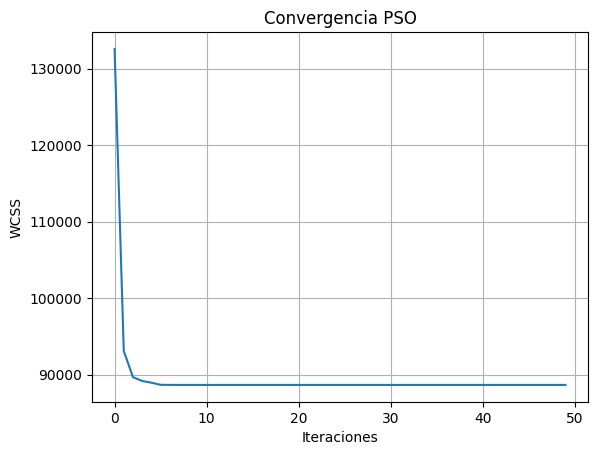

In [6]:
plt.plot(history)
plt.title("Convergencia PSO")
plt.xlabel("Iteraciones")
plt.ylabel("WCSS")
plt.grid()
plt.show()

## PCA y Gráfico de Convergencia

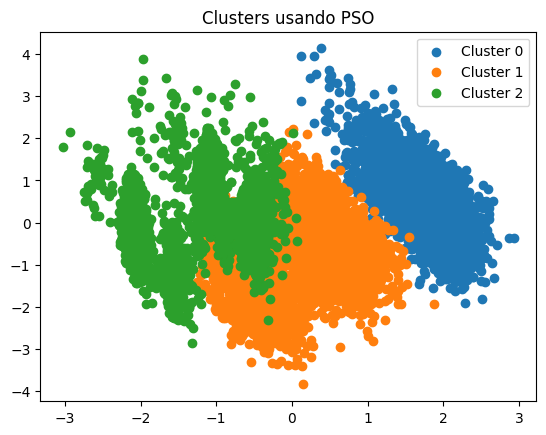

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
for i in range(n_clusters):
    plt.scatter(
        X_pca[labels_pso == i, 0],
        X_pca[labels_pso == i, 1],
        label=f"Cluster {i}"
    )

plt.title("Clusters usando PSO")
plt.legend()
plt.show()

## Comparación con K-Means

In [8]:
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

# WCSS
def calcular_wcss(X, labels, centroids):
    total = 0
    for i in range(len(X)):
        total += np.linalg.norm(X[i] - centroids[labels[i]])**2
    return total

wcss_pso = calcular_wcss(X_scaled, labels_pso, pso.gbest)
wcss_kmeans = kmeans.inertia_

print("WCSS PSO:", wcss_pso)
print("WCSS KMeans:", wcss_kmeans)

WCSS PSO: 88662.50030936903
WCSS KMeans: 88348.89863443052


## Gráfico K-Means


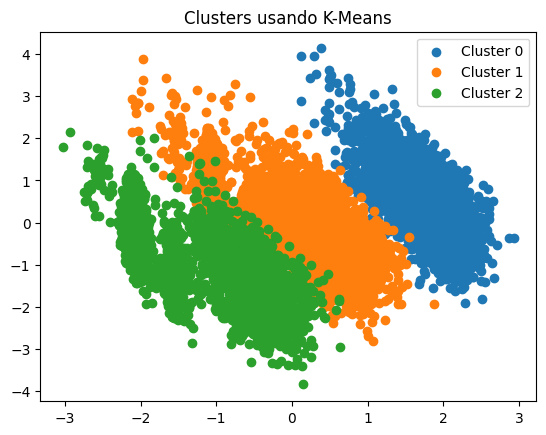

In [9]:
plt.figure()
for i in range(n_clusters):
    plt.scatter(
        X_pca[labels_kmeans == i, 0],
        X_pca[labels_kmeans == i, 1],
        label=f"Cluster {i}"
    )

plt.title("Clusters usando K-Means")
plt.legend()
plt.show()